<a href="https://colab.research.google.com/github/ksayyed150921-maker/Customer-Segmentation-Churn-Pattern-Analytics-in-European-Banking/blob/main/Customer_Segmentation_%26_Churn_Pattern_Analytics_in_European_Banking_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Segmentation & Churn Pattern Analytics in European Banking**

**Project Objectives**

---



• Measure overall churn rate

• Identify churn distribution across customer segments

• Compare churn behavior across European regions

**Secondary Objectives**

---



• Understand churn among high-value customers

• Evaluate engagement and tenure patterns

• Support strategic planning and marketing decisions

**Data Ingestion & Validation**

 step 1 : Import required libraries





In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

step 2: Load Dataset

In [ ]:
df=pd.read_csv('/content/European_Bank.csv')
df.head(10)

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,2025,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,2025,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,2025,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,2025,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,2025,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df.describe()


,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
df.isnull().sum()

,0
Year,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
df.shape

(10000, 14)

# Data Cleaning
Remove unnecessary columns.

In [ ]:
df = df.drop(['CustomerId','Surname'], axis=1)
df.head()

,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Segment
0,2025,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2
1,2025,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,3
2,2025,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,3
3,2025,699,France,Female,39,1,0.00,2,0,0,93826.63,0,2
4,2025,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0


# Encode Categorical Data

Convert text columns to numbers.

In [ ]:
df = pd.get_dummies(df, columns=['Geography','Gender'], drop_first=True)

df.head()

,Year,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Segment,Geography_Germany,Geography_Spain,Gender_Male
0,2025,619,42,2,0.00,1,1,1,101348.88,1,2,False,False,False
1,2025,608,41,1,83807.86,1,0,1,112542.58,0,3,False,True,False
2,2025,502,42,8,159660.80,3,1,0,113931.57,1,3,False,False,False
3,2025,699,39,1,0.00,2,0,0,93826.63,0,2,False,False,False
4,2025,850,43,2,125510.82,1,1,1,79084.10,0,0,False,True,False


**Measure Overall Churn Rate (Primary Objective)**

In [ ]:
churn_rate = df['Exited'].mean() * 100

print("Overall Churn Rate:", churn_rate)

Overall Churn Rate: 20.369999999999997


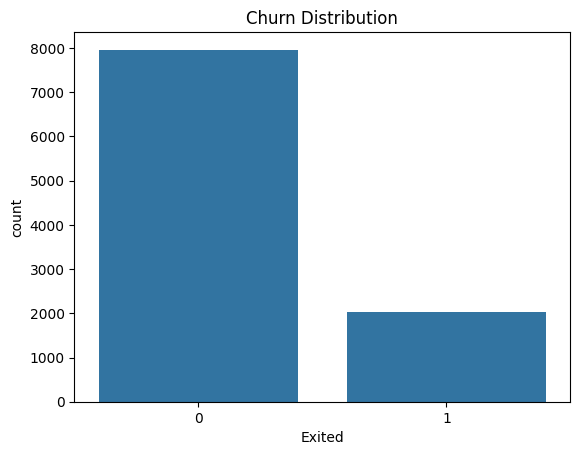

In [ ]:
sns.countplot(x='Exited', data=df)
plt.title("Churn Distribution")
plt.show()


**Churn Distribution Across Customer Segments**

Age vs Churn
---



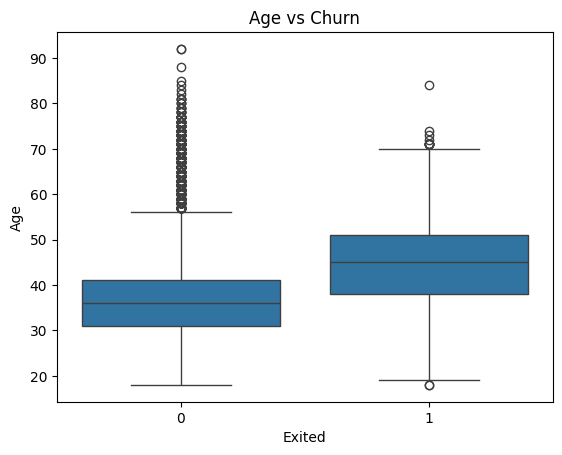

In [ ]:
sns.boxplot(x='Exited', y='Age', data=df)
plt.title("Age vs Churn")
plt.show()

Gender vs Churn:

---



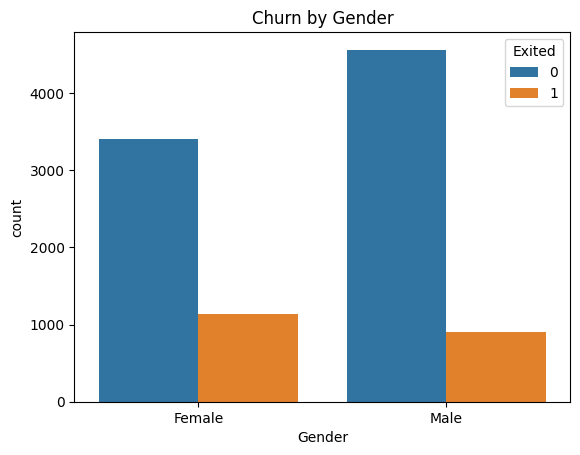

In [ ]:
sns.countplot(x='Gender', hue='Exited', data=df)
plt.title("Churn by Gender")
plt.show()

Balance vs Churn

---



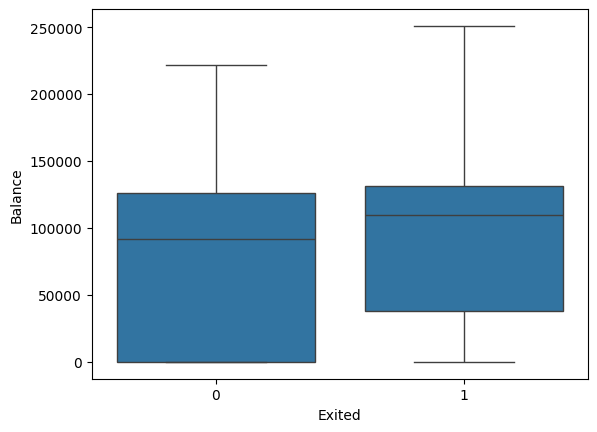

In [ ]:
sns.boxplot(x='Exited', y='Balance', data=df)
plt.show()

**Churn Behavior by Geography (European Regions)**

In [ ]:
geo_churn = pd.crosstab(df['Geography'], df['Exited'])

print(geo_churn)

Exited        0    1
Geography           
France     4204  810
Germany    1695  814
Spain      2064  413


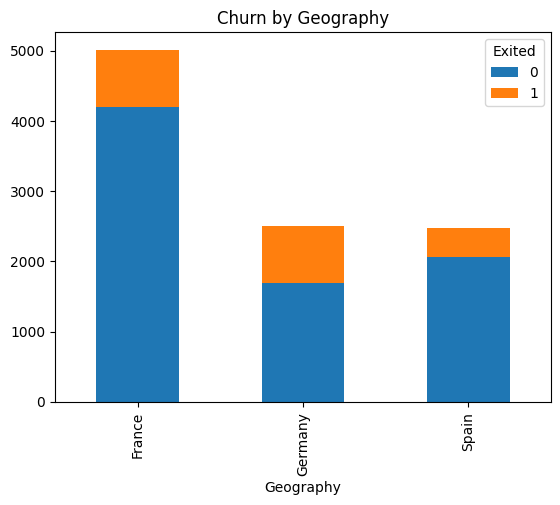

In [ ]:
geo_churn.plot(kind='bar', stacked=True)
plt.title("Churn by Geography")
plt.show()

# Observation:

you will likely see:

Germany → Highest churn

France → Medium

Spain → Lowest

# **High Value Customer Churn Analysis**


High value customers often have:

High Balance

High Salary

In [ ]:
high_value=df[df['Balance']>100000]
high_value['Exited'].value_counts()

,count
Exited,
0,3588
1,1211


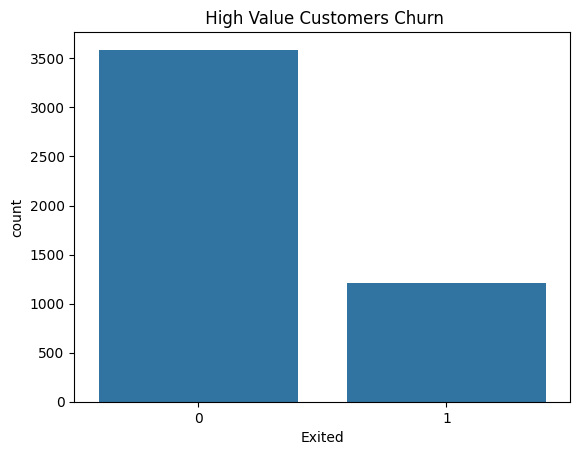

In [ ]:
sns.countplot(x='Exited',data=high_value)
plt.title(' High Value Customers Churn')
plt.show()


# Engagement and Tenure Analysis

Tenure vs Churn

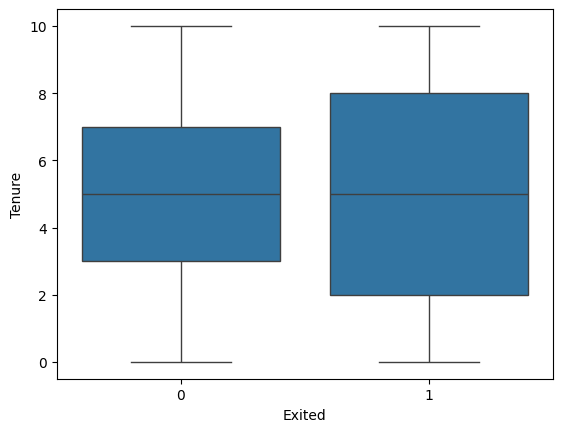

In [ ]:
sns.boxplot(x='Exited',y='Tenure',data=df)
plt.show()

Active Member vs Churn

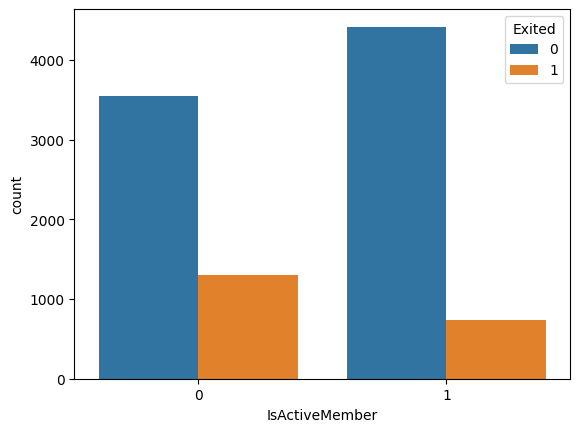

In [ ]:
sns.countplot(x='IsActiveMember',hue='Exited',data=df)
plt.show()

Observation:

Insights usually show:

✔ inactive members churn more

✔ short tenure customers churn more

**Customer Segmentation using K-Means**

Segment customers based on financial behaviour.

Select features

In [ ]:
features = df[['CreditScore','Age','Balance','EstimatedSalary']]

scaler = StandardScaler()

scaled_data = scaler.fit_transform(features)

Apply clustering

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)

df['Segment'] = kmeans.fit_predict(scaled_data)

df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Segment
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,3
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,3
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,2
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0


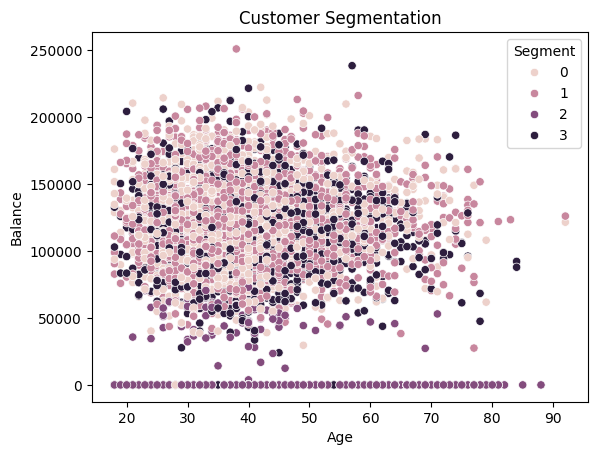

In [ ]:
sns.scatterplot(x=df['Age'], y=df['Balance'], hue=df['Segment'])
plt.title("Customer Segmentation")
plt.show()

Example segments:

Segment------	Type

0--------	     Young low balance

1--------	     High salary professionals

2--------    	Senior wealthy customers

3--------   	Medium income customers

# **Churn by Customer Segment**

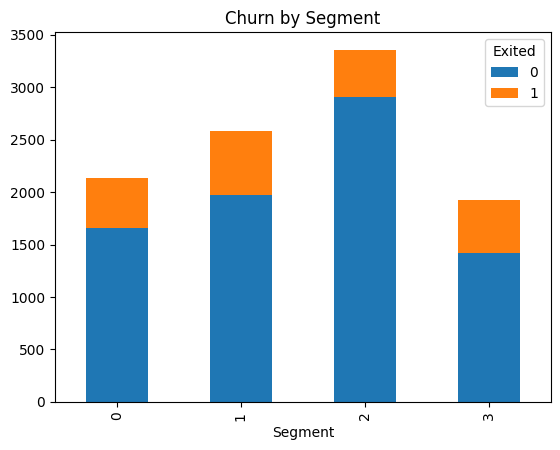

In [ ]:
segment_churn = pd.crosstab(df['Segment'], df['Exited'])

segment_churn.plot(kind='bar', stacked=True)
plt.title("Churn by Segment")
plt.show()

# Financial Profile of Churned Customers

In [ ]:
churned = df[df['Exited'] == 1]

churned[['Balance','EstimatedSalary','CreditScore']].describe()

,Balance,EstimatedSalary,CreditScore
count,2037.000000,2037.000000,2037.000000
mean,91108.539337,101465.677531,645.351497
std,58360.794816,57912.418071,100.321503
min,0.000000,11.580000,350.000000
25%,38340.020000,51907.720000,578.000000
50%,109349.290000,102460.840000,646.000000
75%,131433.330000,152422.910000,716.000000
max,250898.090000,199808.100000,850.000000


Obsevation:

This helps answer:

✔ Are churned customers rich?

✔ Are they high credit customers?

# **Key Business Insights

Example insights:

1️⃣ Overall churn rate = ~20%

2️⃣ Germany shows highest churn

3️⃣ Customers aged 40–60 churn more

4️⃣ Inactive members have higher churn probability

5️⃣ High balance customers show moderate churn risk

6️⃣ Customers with short tenure (<3 years) churn more

Strategic Recommendations

Banks can:

• Target high-risk segments with loyalty offers

• Improve engagement of inactive members

• Create region-specific retention strategies

• Monitor high-balance customers






